In [9]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact
import math
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial.transform import Rotation as R
import quaternion
import matplotlib as mpl

ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.11/dist-packages/numpy/_core/umath.py)

In [ ]:
pip install --upgrade --force-reinstall numpy-quaternion

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 19.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 1.0000000e+00,  0.0000000e+00,  6.1232340e-17],
       [ 1.0000000e+00,  0.0000000e+00, -3.0000000e+00],
       [ 1.0000000e+00,  2.0000000e+00, -3.0000000e+00],
       [ 1.0000000e+00,  2.0000000e+00,  6.1232340e-17],
       [ 1.8369702e-16,  0.0000000e+00, -3.0000000e+00],
       [ 1.8369702e-16,  2.0000000e+00, -3.0000000e+00],
       [ 0.0000000e+00,  2.0000000e+00,  0.0000000e+00]])

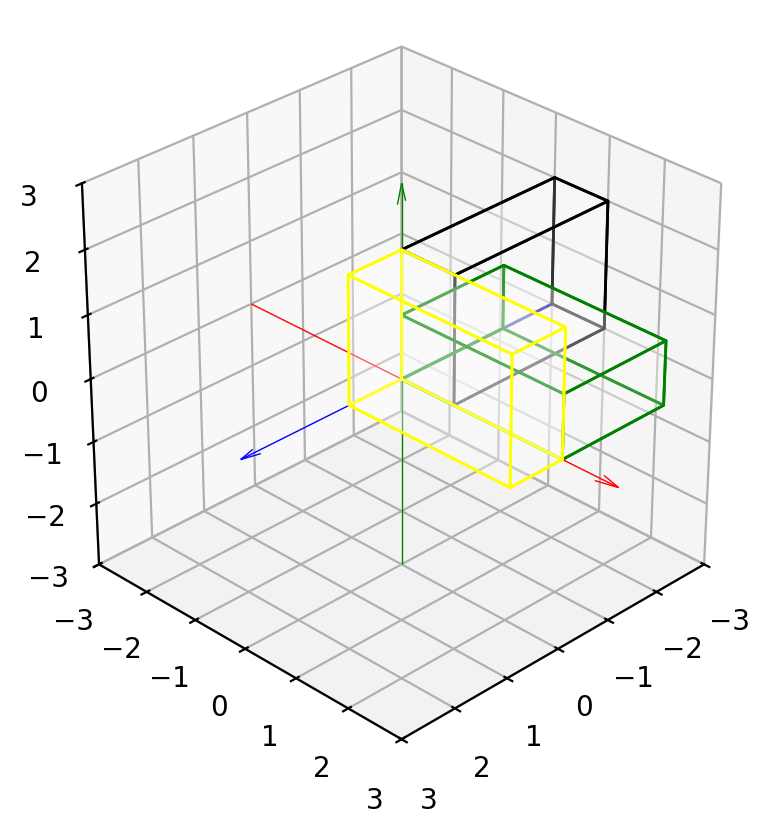

In [ ]:
X = np.array([0,0,3,3,0,3,3,0])
Y = np.array([0,0,0,2,2,0,2,2])
Z = np.array([0,1,1,1,1,0,0,0])
XYZ = np.array([
    [0, 0, 0], # 0
    [0, 0, 1], # 1
    [3, 0, 1], # 2
    [3, 2, 1], # 3
    [0, 2, 1], # 4
    [3, 0, 0], # 5
    [3, 2, 0], # 6
    [0, 2, 0], # 7
])

faces = np.array([
    [0, 7, 4, 1],
    [1, 0, 5, 2],
    [0, 7, 6, 5],
    [4, 7, 6, 3],
    [3, 2, 5, 6],
    [1, 2, 3, 4],
])

def Rotaion(t):
    trad = np.radians(t)
    Rx = np.array([[1,0,0],[0,np.cos(trad),-np.sin(trad)],[0,np.sin(trad),np.cos(trad)]])
    Ry = np.array([[np.cos(trad),0,np.sin(trad)],[0,1,0],[-np.sin(trad),0,np.cos(trad)]])
    Rz = np.array([[np.cos(trad),-np.sin(trad),0],[np.sin(trad),np.cos(trad),0],[0,0,1]])
    return Rx,Ry,Rz


fig01 = plt.figure(num=1,dpi=200)
ax01 = fig01.add_subplot(1,1,1,projection='3d')
ax01.grid(ls='--',lw=0.5,color='lightgrey')
ax01.set_aspect('equal')
ax01.set_xlim(-3, 3)
ax01.set_ylim(-3, 3)
ax01.set_zlim(-3, 3)
ax01.quiver(-3, 0, 0, 7, 0, 0, color='red', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
ax01.quiver(0, -3, 0, 0, 6, 0, color='green', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
ax01.quiver(0, 0, -3, 0, 0, 6, color='blue', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
ax01.view_init(azim=45,vertical_axis='y')
ax01.add_collection3d(col=Poly3DCollection(verts=[XYZ[i] for i in faces], edgecolors='yellow',alpha=0.2,facecolors='white'))
Rx,Ry,Rz = Rotaion(90)
XYZ1 = XYZ @ Ry.T
Rx,Ry,Rz = Rotaion(-90)
XYZ3 = XYZ @ Rx.T
ax01.add_collection3d(col=Poly3DCollection(verts=[XYZ1[i] for i in faces], edgecolors='black',alpha=0.2,facecolors='white'))
ax01.add_collection3d(col=Poly3DCollection(verts=[XYZ3[i] for i in faces], edgecolors='green',alpha=0.2,facecolors='white'))
XYZ1

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00,  0.00000000e+00,  2.22044605e-16],
       [ 1.00000000e+00,  0.00000000e+00, -3.00000000e+00],
       [ 1.00000000e+00,  2.00000000e+00, -3.00000000e+00],
       [ 1.00000000e+00,  2.00000000e+00,  2.22044605e-16],
       [ 6.66133815e-16,  0.00000000e+00, -3.00000000e+00],
       [ 6.66133815e-16,  2.00000000e+00, -3.00000000e+00],
       [ 0.00000000e+00,  2.00000000e+00,  0.00000000e+00]])

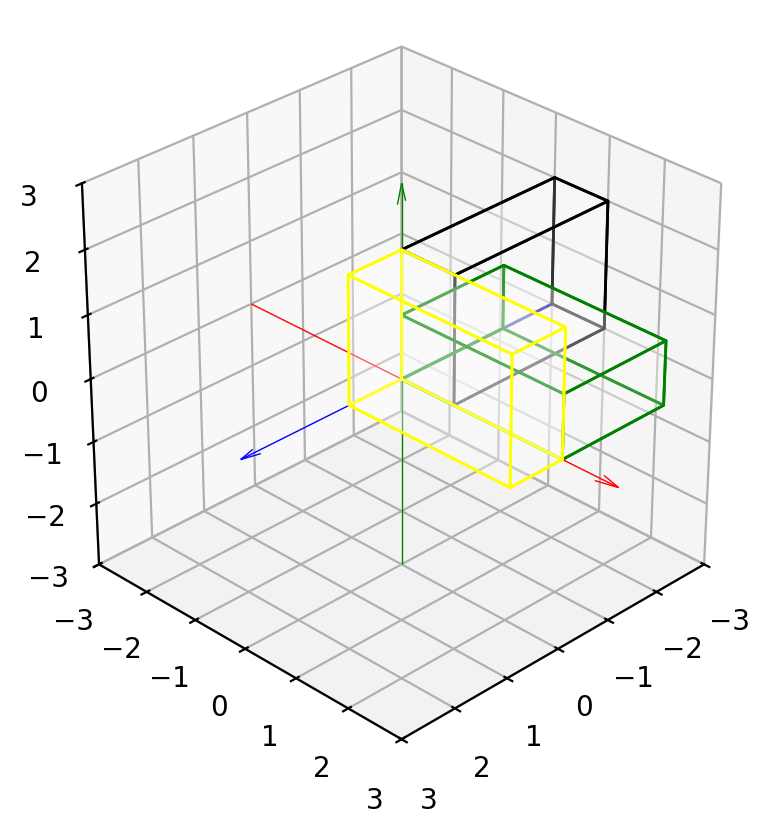

In [ ]:
fig01 = plt.figure(num=1,dpi=200)
ax01 = fig01.add_subplot(1,1,1,projection='3d')
ax01.grid(ls='--',lw=0.5,color='lightgrey')
ax01.set_aspect('equal')
ax01.set_xlim(-3, 3)
ax01.set_ylim(-3, 3)
ax01.set_zlim(-3, 3)
ax01.quiver(-3, 0, 0, 7, 0, 0, color='red', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
ax01.quiver(0, -3, 0, 0, 6, 0, color='green', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
ax01.quiver(0, 0, -3, 0, 0, 6, color='blue', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
ax01.view_init(azim=45,vertical_axis='y')

eulery = R.from_euler('y',90,degrees=True)
eulerx = R.from_euler('x',-90,degrees=True)
eulery_r = eulery.as_matrix()
eulerx_r = eulerx.as_matrix()
XYZ2 = XYZ @ eulery_r.T
XYZ4 = XYZ @ eulerx_r.T
ax01.add_collection3d(col=Poly3DCollection(verts=[XYZ2[i] for i in faces], edgecolors='black',alpha=0.2,facecolors='white'))
ax01.add_collection3d(col=Poly3DCollection(verts=[XYZ[i] for i in faces], edgecolors='yellow',alpha=0.2,facecolors='white'))
ax01.add_collection3d(col=Poly3DCollection(verts=[XYZ4[i] for i in faces], edgecolors='green',alpha=0.2,facecolors='white'))
XYZ2

In [ ]:
def task2(t):
    rad = np.radians(t)
    xyz = np.array([[0,0,0],
                    [0,1,0],
                    [1,1,0],
                    [1,0,0],
                    [0,0,1],
                    [0,1,1],
                    [1,1,1],
                    [1,0,1]
                    ])
    faces1 = np.array([[0,1,2,3],
                       [4,5,6,7],
                       [0,1,5,4],
                       [2,3,7,6],
                       [1,2,6,5],
                       [0,3,7,4]
                      ])
    a = np.array([1,1,1]) / np.sqrt(3)
    A = np.array([[0,-a[2],a[1]],[a[2],0,-a[0]],[-a[1],a[0],0]])
    R = np.eye(3) + (np.sin(rad) * A) + ((1-np.cos(rad)) * (A @ A))
    xyz1 = xyz @ R.T
    fig02 = plt.figure(num=1,dpi=200)
    ax02 = fig02.add_subplot(1,1,1,projection='3d')
    ax02.grid(ls='--',lw=0.5,color='lightgrey')
    ax02.set_aspect('equal')
    ax02.set_xlim(-1, 1)
    ax02.set_ylim(-1, 1)
    ax02.set_zlim(-1, 1)
    ax02.view_init(azim=25,vertical_axis='y')
    #ax02.quiver(-3, 0, 0, 7, 0, 0, color='red', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
    #ax02.quiver(0, -3, 0, 0, 6, 0, color='green', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
    #ax02.quiver(0, 0, -3, 0, 0, 6, color='blue', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
    ax02.add_collection3d(col=Poly3DCollection(verts=[xyz[i] for i in faces1], edgecolors='black',alpha=0.2,facecolors='white'))
    ax02.add_collection3d(col=Poly3DCollection(verts=[xyz1[i] for i in faces1], edgecolors='purple',alpha=0.2,facecolors='white'))
    ax02.plot([xyz[0][0],xyz[6][0]],[xyz[0][1],xyz[6][1]],[xyz[0][2],xyz[6][2]])
interact(task2,t=(0,360,1))

NameError: name 'interact' is not defined

In [ ]:
def task2_1(t):
    rad = np.radians(t)
    xyz = np.array([[0,0,0],
                    [0,1,0],
                    [1,1,0],
                    [1,0,0],
                    [0,0,1],
                    [0,1,1],
                    [1,1,1],
                    [1,0,1]
                    ])
    faces1 = np.array([[0,1,2,3],
                       [4,5,6,7],
                       [0,1,5,4],
                       [2,3,7,6],
                       [1,2,6,5],
                       [0,3,7,4]
                      ])
    a = np.array([1,1,1]) / np.sqrt(3)
    A = np.array([[0,-a[2],a[1]],[a[2],0,-a[0]],[-a[1],a[0],0]])
    R1 = np.eye(3) + (np.sin(rad) * A) + ((1-np.cos(rad)) * (A @ A))
    R2 = R.from_rotvec(rad * a)
    euler = R2.as_euler('xyz', degrees=True)
    xyz1 = xyz @ R2.as_matrix().T
    fig02 = plt.figure(num=1,dpi=200)
    ax02 = fig02.add_subplot(1,1,1,projection='3d')
    ax02.grid(ls='--',lw=0.5,color='lightgrey')
    ax02.set_aspect('equal')
    ax02.set_xlim(-1, 1)
    ax02.set_ylim(-1, 1)
    ax02.set_zlim(-1, 1)
    ax02.view_init(azim=25,vertical_axis='y')
    #ax02.quiver(-3, 0, 0, 7, 0, 0, color='red', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
    #ax02.quiver(0, -3, 0, 0, 6, 0, color='green', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
    #ax02.quiver(0, 0, -3, 0, 0, 6, color='blue', arrow_length_ratio=0.05, zorder=-10, lw=0.5)
    ax02.add_collection3d(col=Poly3DCollection(verts=[xyz[i] for i in faces1], edgecolors='black',alpha=0.2,facecolors='white'))
    ax02.add_collection3d(col=Poly3DCollection(verts=[xyz1[i] for i in faces1], edgecolors='purple',alpha=0.2,facecolors='white'))
    ax02.plot([xyz[0][0],xyz[6][0]],[xyz[0][1],xyz[6][1]],[xyz[0][2],xyz[6][2]])
    print(R1)
    print(R2.as_matrix())
interact(task2_1,t=(0,360,1))

interactive(children=(IntSlider(value=180, description='t', max=360), Output()), _dom_classes=('widget-interac…

<function __main__.task2_1(t)>

In [ ]:
def task3_1(t):
    rad = np.radians(t)
    fig03 = plt.figure(num=1,dpi=200)
    ax03 = fig03.add_subplot(1,1,1,projection='3d')
    ax03.grid(ls='--',lw=0.5,color='lightgrey')
    ax03.set_aspect('equal')
    xyz = np.array([[1,0,1],
                    [-1,0,1],
                    [-1,0,-1],
                    [1,0,-1],
                    [0,2,0]
                    ])
    faces = [[1,2,3,0],
                 [1,2,4],
                 [2,4,3],
                 [0,4,3],
                 [1,4,0]]
    a = np.array([0,2,0])/2
    la0 = np.cos(rad/2)
    la = (np.sin(rad/2) * a)
    P = xyz + ((2*la0)*np.cross(la,xyz))+2*np.cross(la,np.cross(la,xyz))
    #p = xyz @ la
    ax03.set_xlim(-2, 2)
    ax03.set_ylim(-2, 2)
    ax03.set_zlim(-2, 2)
    ax03.view_init(azim=25,vertical_axis='y')
    print(P)
    ax03.add_collection3d(col=Poly3DCollection(verts=[[xyz[i] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='white'))
    ax03.add_collection3d(col=Poly3DCollection(verts=[[P[i] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='purple'))
interact(task3_1, t = (0,360,1))

interactive(children=(IntSlider(value=180, description='t', max=360), Output()), _dom_classes=('widget-interac…

<function __main__.task3_1(t)>

In [ ]:
def task3_2(t):
    rad = np.radians(t)
    fig03 = plt.figure(num=1,dpi=200)
    ax03 = fig03.add_subplot(1,1,1,projection='3d')
    ax03.grid(ls='--',lw=0.5,color='lightgrey')
    ax03.set_aspect('equal')
    xyz = np.array([[1,0,1],
                    [-1,0,1],
                    [-1,0,-1],
                    [1,0,-1],
                    [0,2,0]
                    ])
    xyz1 = np.array([[0,1,0,1],
                    [0,-1,0,1],
                    [0,-1,0,-1],
                    [0,1,0,-1],
                    [0,0,2,0]
                    ])
    faces = [[1,2,3,0],
                 [1,2,4],
                 [2,4,3],
                 [0,4,3],
                 [1,4,0]]
    a = np.array([-2,0,2])/np.sqrt(8)
    q = np.quaternion(np.cos(rad/2),*np.sin(rad/2)*a)
    #q1 = np.quaternion(np.cos(rad/2),*np.sin(-rad/2)*a)
    xyzq = quaternion.as_quat_array(xyz1)
    P = q * xyzq * q.conjugate()
    P = quaternion.as_float_array(P)
    p = quaternion.as_rotation_matrix(q)
    p = xyz @ p
    ax03.set_xlim(-2, 2)
    ax03.set_ylim(-2, 2)
    ax03.set_zlim(-2, 2)
    ax03.view_init(azim=25,vertical_axis='y')
    #print(P[0][1:])
    #print(p)
    ax03.add_collection3d(col=Poly3DCollection(verts=[[xyz[i] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='white'))
    ax03.add_collection3d(col=Poly3DCollection(verts=[[P[i][1:] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='purple'))
    #ax03.add_collection3d(col=Poly3DCollection(verts=[[p[i] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='purple'))
interact(task3_2, t = (0,360,1))

interactive(children=(IntSlider(value=180, description='t', max=360), Output()), _dom_classes=('widget-interac…

<function __main__.task3_2(t)>

In [ ]:
def task4(t):
    rad = np.radians(t)
    fig03 = plt.figure(num=1,dpi=200)
    ax03 = fig03.add_subplot(1,1,1,projection='3d')
    ax03.grid(ls='--',lw=0.5,color='lightgrey')
    ax03.set_aspect('equal')
    xyz = np.array([[1,0,1],
                    [-1,0,1],
                    [-1,0,-1],
                    [1,0,-1],
                    [0,2,0]
                    ])
    faces = [[1,2,3,0],
                 [1,2,4],
                 [2,4,3],
                 [0,4,3],
                 [1,4,0]]
    ax03.add_collection3d(col=Poly3DCollection(verts=[[xyz[i] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='white'))
    a = np.array([0,2,0])/np.sqrt(4)
    xyz = xyz - np.array([1,0,-1])
    la0 = np.cos(rad/2)
    la = (np.sin(rad/2) * a)
    P = xyz + ((2*la0)*np.cross(la,xyz))+2*np.cross(la,np.cross(la,xyz))
    #p = xyz @ la
    P+=np.array([1,0,-1])
    ax03.set_xlim(-2, 2)
    ax03.set_ylim(-2, 2)
    ax03.set_zlim(-2, 2)
    ax03.view_init(azim=25,vertical_axis='y')
    #print(np.linalg.norm(a))

    ax03.add_collection3d(col=Poly3DCollection(verts=[[P[i] for i in i1] for i1 in faces], edgecolors='black',alpha=0.2,facecolors='purple'))
interact(task4, t = (0,360,1))

interactive(children=(IntSlider(value=180, description='t', max=360), Output()), _dom_classes=('widget-interac…

<function __main__.task4(t)>